# 09 — Spatial Behaviour

## The gap this fills

Notebooks 04 through 08 treat a tap as an **event in time**: when it happened, how long it
lasted, what the handset felt. Not one of them asks **where on the glass it landed**.

That is a large omission. Every `touchstart` carries a coordinate, and where a thumb can
comfortably reach is determined by hand size, grip, and which hand is holding the phone —
none of which are captured by any timing feature.

## What spatial behaviour physically is

```
        ┌─────────────────┐
        │                 │   the top of a large phone is hard
        │   hard to       │   to reach with the holding thumb
        │   reach         │
        │ ┌─────────────┐ │
        │ │             │ │   the thumb sweeps an ARC, pivoting
        │ │  comfort    │ │   at the base — not a straight line
        │ │  arc        │ │
        │ └─────────────┘ │
        │  ●              │   pivot point differs left vs right hand
        └─────────────────┘
```

Three things vary between people and none of them are pace:

| aspect | what it reflects |
|---|---|
| **where the cloud sits** | which hand holds the phone, and how far the thumb reaches |
| **how wide the cloud is** | grip stability and how precisely someone aims |
| **where they land on a *fixed* target** | systematic aiming bias — the cleanest measurement here |

## The measurement problem, and why this notebook is unusually clean

Everywhere else in this project, comparing participants means arguing away confounds — task
differences, pace, device. Spatial behaviour has an unusually good answer available:
**the app contains targets that appear in the same place in every session.**

`continue_button` is tapped 890 times across all 29 sessions. The passcode keypad appears in
every session with fixed key positions. For those targets, task semantics, target size and
target position are all held constant by construction — so a difference in where someone
lands is about the person, not the task.

Sections 7 and 8 lean on this heavily. It is the strongest natural control in the dataset.

## What this notebook does not do

No scoring, no ranking, no verdict. Coordinates are normalised (`xNorm`, `yNorm`) so
different screen sizes are comparable, but Section 2 checks whether that normalisation is
actually trustworthy before anything is built on it.

## Sections

1. Setup
2. Screen geometry — is normalisation trustworthy?
3. The tap cloud — where people actually touch
4. Reach envelope — how much of the screen gets used
5. Horizontal bias — the handedness signal
6. Vertical zones — what is comfortable to reach
7. A controlled target: `continue_button`
8. A controlled keypad: the passcode
9. Aim precision on a fixed target
10. Contact size — what the touch radius reveals
11. Spatial drift across a session
12. Gesture geometry — where strokes start and end
13. Does any of this hold within a person?
14. Availability and data-quality notes
15. Per-participant cards
16. Open questions

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 210)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
                     'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

_CANDIDATES = ["../../data/processed/raw_events.parquet",
               "data/processed/raw_events.parquet",
               "raw_events.parquet",
               "/mnt/user-data/uploads/raw_events.parquet"]
_src = next((p for p in _CANDIDATES if Path(p).exists()), None)
if _src is None:
    raise FileNotFoundError(f"no raw events file found; tried {_CANDIDATES}")
raw_all = pd.read_parquet(_src)
raw_all['deviceFamily'] = raw_all['deviceFamily'].astype(str).str.lower()
raw_all['tRelMs'] = pd.to_numeric(raw_all['tRelMs'], errors='coerce')
raw_all = raw_all.loc[raw_all['tRelMs'].notna()].copy()
raw = raw_all.loc[raw_all['deviceFamily'] == 'mobile'].copy()

TAP = 'touchstart'
session_index = (raw.groupby(['participantId', 'sessionId'], dropna=False)
                 .agg(duration_s=('tRelMs', lambda s: s.max() / 1000.0),
                      started=('timestampIso', 'min'),
                      device=('deviceModel', 'first')).reset_index())
session_index['session_start'] = pd.to_datetime(session_index['started'], utc=True, errors='coerce')
session_index = session_index.sort_values(['participantId', 'session_start']).reset_index(drop=True)
session_index['session_no'] = session_index.groupby('participantId').cumcount() + 1
SESSION_LABEL = {r.sessionId: f"{r.participantId} s{r.session_no}" for r in session_index.itertuples()}
SESSION_ORDER = session_index.sort_values(['participantId', 'session_no'])['sessionId'].tolist()

taps = raw.loc[raw['kind'] == TAP].copy()
for c in ['payload_x', 'payload_y', 'payload_xNorm', 'payload_yNorm', 'payload_radiusX']:
    taps[c] = pd.to_numeric(taps[c], errors='coerce')
taps = taps.dropna(subset=['payload_xNorm', 'payload_yNorm'])

_n = taps.groupby('participantId').size().sort_values(ascending=False)
PARTICIPANTS = _n.index.astype(str).tolist()
_QUAL = plt.get_cmap('tab10')
PCOL = {p: _QUAL(i % 10) for i, p in enumerate(PARTICIPANTS)}
def pcolor(p): return PCOL.get(str(p), '0.5')

print(f"Loaded {_src}")
print(f"{len(taps):,} taps with coordinates across {taps['sessionId'].nunique()} sessions, "
      f"{len(PARTICIPANTS)} participants\n")
for p in PARTICIPANTS:
    d = session_index.loc[session_index['participantId'] == p]
    print(f"  {p}  {_n[p]:5,} taps   {len(d)} session(s)   {d['device'].iloc[0]}")

Loaded /mnt/user-data/uploads/raw_events.parquet
4,806 taps with coordinates across 29 sessions, 10 participants

  pH3S4X4  1,486 taps   8 session(s)   iphone_13_13_mini
  p95MPVX    733 taps   4 session(s)   older_iphone
  pG5G4MS    729 taps   6 session(s)   iphone_16_plus
  p3YDMHG    459 taps   4 session(s)   iphone_16_plus
  pA6XL23    407 taps   2 session(s)   iphone_16
  pZMC82M    282 taps   1 session(s)   iphone_15
  p3M6E7Z    194 taps   1 session(s)   iphone_16_plus
  pAFQRTM    191 taps   1 session(s)   older_iphone
  pWS9VTN    189 taps   1 session(s)   iphone_13_pro_pro_max
  pUNKH7L    136 taps   1 session(s)   older_iphone


## 2. Screen geometry — is normalisation trustworthy?

Every coordinate here is used in **normalised** form: `xNorm` and `yNorm` run 0 to 1 across
the viewport, so a tap two-thirds of the way across the screen reads as 0.67 whether the
phone is an iPhone 13 mini or a 16 Plus.

That is what makes cross-participant comparison possible at all — but it is only valid if
the normalisation denominator is stable. Two things could break it:

- **The viewport changes size mid-session** when the keyboard appears or the browser chrome
  hides. If `yNorm` is computed against a viewport that shrank, the same physical position
  reports a different number.
- **Different devices have different aspect ratios**, so equal `yNorm` does not mean equal
  physical distance from the thumb pivot.

Both are checked before anything is built on the normalisation, and **one of them fails** —
see the result below the plot.

Viewport per session. h_range is how much the viewport height moved WITHIN a session
(keyboard appearing, browser chrome hiding):

   session  w_med  h_med  h_range  aspect   n
p3M6E7Z s1  430.0  782.0   386.67   1.819 121
p3YDMHG s3  430.0  780.0   387.00   1.814  45
p3YDMHG s1  430.0  783.0   387.00   1.821  49
p3YDMHG s4  430.0  785.0   387.00   1.826  75
p3YDMHG s2  430.0  786.0   387.00   1.828 152
p95MPVX s4  375.0  672.0   444.00   1.792 197
p95MPVX s2  375.0  669.0   386.02   1.784 290
p95MPVX s3  375.0  675.0   386.02   1.800 204
p95MPVX s1  375.0  679.0   386.02   1.811 407
pA6XL23 s1  393.0  718.0   377.00   1.827 184
pA6XL23 s2  393.0  707.0   377.02   1.799 125
pAFQRTM s1  375.0  675.5   439.00   1.801 186
pG5G4MS s5  430.0  804.0   387.00   1.870  75
pG5G4MS s3  430.0  804.5   387.00   1.871  82
pG5G4MS s4  430.0  786.0   387.00   1.828  73
pG5G4MS s1  430.0  789.5   387.00   1.836  52
pG5G4MS s2  430.0  787.0   387.00   1.830  57
pG5G4MS s6  430.0  806.0   387.00   1.874

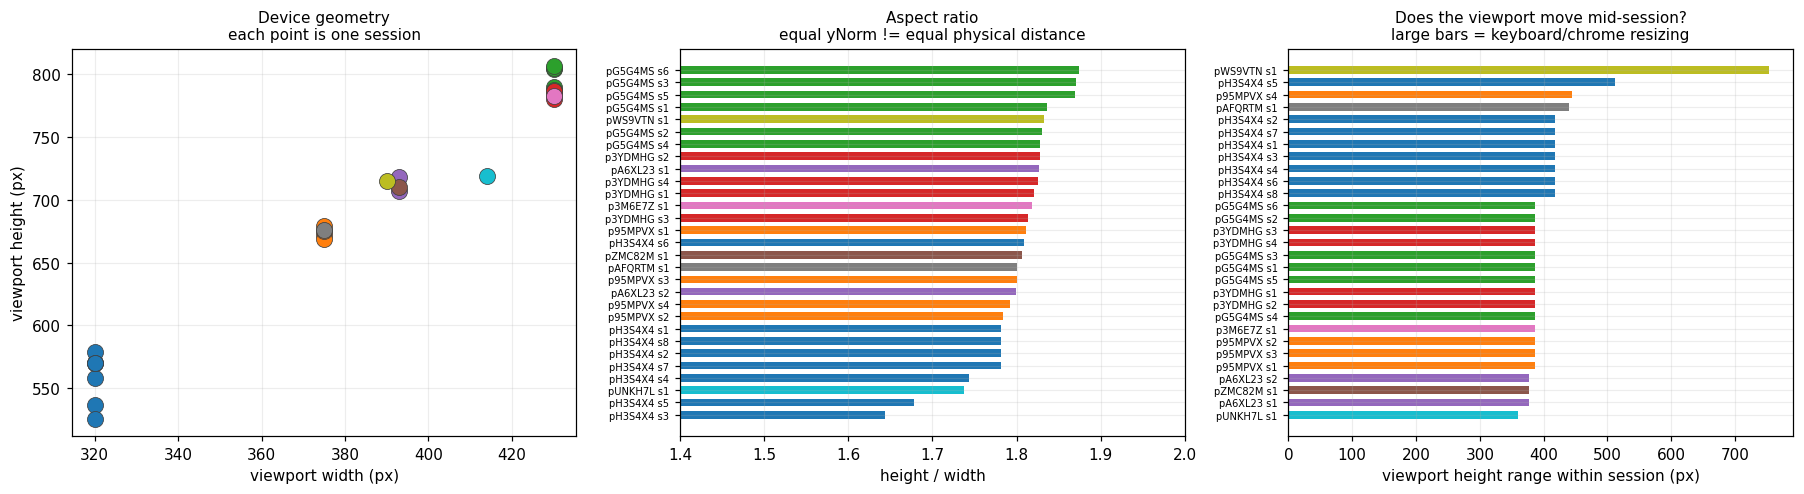


median within-session viewport height range: 387 px
aspect ratio spans 1.64 to 1.87 across devices

THE HEIGHT CHECK FAILS. The viewport loses roughly half its height mid-session,
because the on-screen keyboard opens (one session: 605 px down to 187 px, with
102 distinct intermediate heights as it animates).

yNorm is computed against the VISUAL viewport, so its denominator shrinks whenever
the keyboard is up. The same physical position therefore reports a different yNorm
depending on whether someone was typing at the time.

Viewport WIDTH does not change when the keyboard opens. So:
   xNorm  -- trustworthy, used as the primary spatial measure in this notebook
   yNorm  -- viewport-relative, not screen-relative. Read with caution, and never
             compare a typing task against a non-typing one on this axis.


In [2]:
vp = raw.loc[raw['kind'].isin(['visual_viewport_resize', 'resize'])].copy()
for c in ['payload_viewportWidth', 'payload_viewportHeight',
          'payload_innerWidth', 'payload_innerHeight']:
    if c in vp.columns:
        vp[c] = pd.to_numeric(vp[c], errors='coerce')
vp['w'] = vp.get('payload_viewportWidth', pd.Series(dtype=float)).fillna(
    vp.get('payload_innerWidth', pd.Series(dtype=float)))
vp['h'] = vp.get('payload_viewportHeight', pd.Series(dtype=float)).fillna(
    vp.get('payload_innerHeight', pd.Series(dtype=float)))
vp = vp.dropna(subset=['w', 'h'])

geo = (vp.groupby(['participantId', 'sessionId'])
       .agg(w_med=('w', 'median'), h_med=('h', 'median'),
            h_min=('h', 'min'), h_max=('h', 'max'), n=('h', 'size')).reset_index())
geo['h_range'] = geo['h_max'] - geo['h_min']
geo['aspect'] = (geo['h_med'] / geo['w_med']).round(3)
geo['session'] = geo['sessionId'].map(SESSION_LABEL)
print("Viewport per session. h_range is how much the viewport height moved WITHIN a session")
print("(keyboard appearing, browser chrome hiding):\n")
print(geo[['session', 'w_med', 'h_med', 'h_range', 'aspect', 'n']].to_string(index=False))


def plot_geometry(geo):
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))
    ax = axes[0]
    for p in PARTICIPANTS:
        d = geo.loc[geo['participantId'] == p]
        ax.scatter(d['w_med'], d['h_med'], s=110, color=pcolor(p), edgecolor='0.25',
                   lw=0.5, zorder=3)
    ax.set_xlabel("viewport width (px)"); ax.set_ylabel("viewport height (px)")
    ax.set_title("Device geometry\neach point is one session", fontsize=10)

    ax = axes[1]
    d = geo.sort_values('aspect')
    y = np.arange(len(d))
    ax.barh(y, d['aspect'], color=[pcolor(p) for p in d['participantId']], height=0.62)
    ax.set_yticks(y); ax.set_yticklabels(d['session'], fontsize=6.5)
    ax.set_xlim(1.4, max(2.0, d['aspect'].max() * 1.02))
    ax.set_xlabel("height / width")
    ax.set_title("Aspect ratio\nequal yNorm != equal physical distance", fontsize=10)

    ax = axes[2]
    d2 = geo.sort_values('h_range')
    y = np.arange(len(d2))
    ax.barh(y, d2['h_range'], color=[pcolor(p) for p in d2['participantId']], height=0.62)
    ax.set_yticks(y); ax.set_yticklabels(d2['session'], fontsize=6.5)
    ax.set_xlabel("viewport height range within session (px)")
    ax.set_title("Does the viewport move mid-session?\nlarge bars = keyboard/chrome resizing",
                 fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)
    print(f"\nmedian within-session viewport height range: {geo['h_range'].median():.0f} px")
    print(f"aspect ratio spans {geo['aspect'].min():.2f} to {geo['aspect'].max():.2f} across devices")
    print()
    print("=" * 78)
    print("THE HEIGHT CHECK FAILS. The viewport loses roughly half its height mid-session,")
    print("because the on-screen keyboard opens (one session: 605 px down to 187 px, with")
    print("102 distinct intermediate heights as it animates).")
    print()
    print("yNorm is computed against the VISUAL viewport, so its denominator shrinks whenever")
    print("the keyboard is up. The same physical position therefore reports a different yNorm")
    print("depending on whether someone was typing at the time.")
    print()
    print("Viewport WIDTH does not change when the keyboard opens. So:")
    print("   xNorm  -- trustworthy, used as the primary spatial measure in this notebook")
    print("   yNorm  -- viewport-relative, not screen-relative. Read with caution, and never")
    print("             compare a typing task against a non-typing one on this axis.")
    print("=" * 78)


plot_geometry(geo)

## 3. The tap cloud — where people actually touch

The simplest possible spatial view: every tap a participant made, plotted on a normalised
screen. Origin top-left, matching browser coordinates, so the plot is oriented the way the
phone is held.

Look for three things:

- **Where the mass sits.** A cloud shifted left or right is the strongest handedness clue.
- **How tight it is.** A concentrated cloud means someone who returns to the same regions;
  a diffuse one means a wandering thumb.
- **Empty regions.** Corners nobody reaches are as informative as the ones they do.

Note this pools *all* taps, so part of the shape is dictated by where the app puts its
controls. Sections 7 and 8 remove that by fixing the target.

/tmp/ipykernel_554/761011552.py:9: UserWarning: You passed a edgecolor/edgecolors ((np.float64(0.12156862745098039), np.float64(0.4666666666666667), np.float64(0.7058823529411765), np.float64(1.0))) for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(d['payload_xNorm'].median(), d['payload_yNorm'].median(),
/tmp/ipykernel_554/761011552.py:9: UserWarning: You passed a edgecolor/edgecolors ((np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0))) for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(d['payload_xNorm'].median(), d['payload_yNorm'].median(),
/tmp/ipykernel_554/761011552.py:9: UserWarning: You passed a edgecolor/edgecolors ((np.float64(0.17254901960784313), np.float64(0.6274509803921569), np.float64(0.17254901960784313), np.float64(1.0))) fo

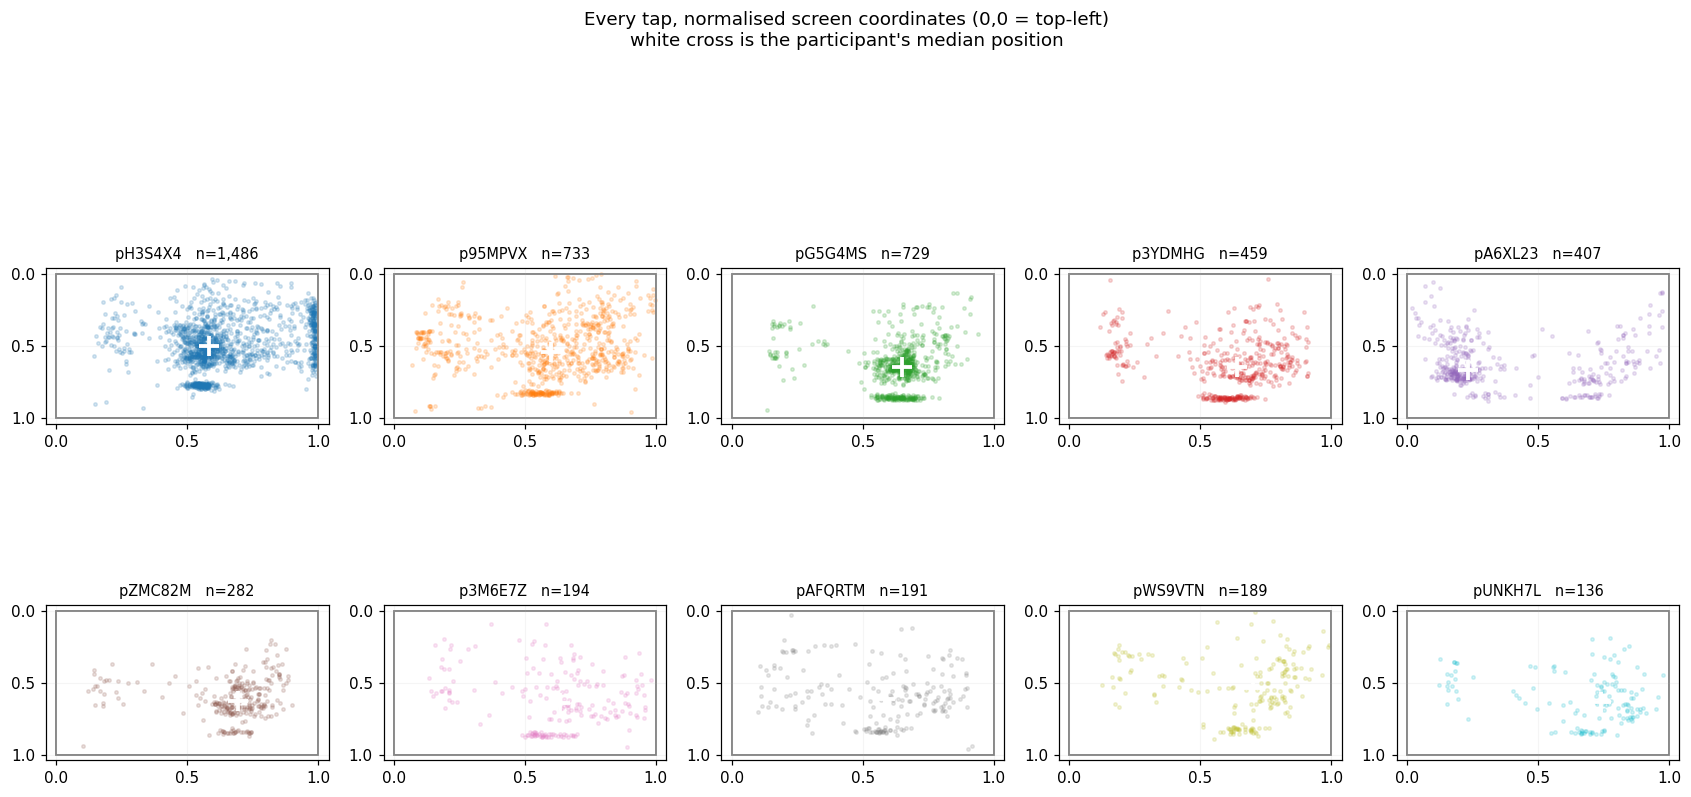

In [3]:
def plot_tap_clouds(taps):
    n = len(PARTICIPANTS); ncol = 5
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(15.5, 4.2 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, p in zip(axes, PARTICIPANTS):
        d = taps.loc[taps['participantId'] == p]
        ax.scatter(d['payload_xNorm'], d['payload_yNorm'], s=5, alpha=0.18, color=pcolor(p))
        ax.scatter(d['payload_xNorm'].median(), d['payload_yNorm'].median(),
                   s=180, color='white', edgecolor=pcolor(p), lw=2.5, zorder=5, marker='+')
        ax.add_patch(Rectangle((0, 0), 1, 1, fill=False, edgecolor='0.5', lw=1.2))
        ax.set_xlim(-0.04, 1.04); ax.set_ylim(1.04, -0.04)
        ax.set_aspect(0.55)
        ax.set_xticks([0, 0.5, 1]); ax.set_yticks([0, 0.5, 1])
        ax.set_title(f"{p}   n={len(d):,}", fontsize=9.5)
        ax.grid(alpha=0.12)
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle("Every tap, normalised screen coordinates (0,0 = top-left)\n"
                 "white cross is the participant's median position", y=1.0)
    plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show(); plt.close(fig)


plot_tap_clouds(taps)

## 4. Reach envelope — how much of the screen gets used

The cloud above shows *where*; this asks *how much*. Two people can share a median position
and use completely different amounts of the screen.

- **Spread** (interquartile range in each axis) — the size of the comfortable region.
- **Coverage** — what fraction of a coarse screen grid a person ever touches. A low value
  means someone working within a narrow band; a high value means using the whole display.

Coverage is bounded by how many taps someone made, so the count is reported alongside and
the comparison is only meaningful between participants with similar volumes.

participant  n_taps  x_iqr  y_iqr  cells_touched  coverage
    pH3S4X4    1486  0.201  0.211             47     0.734
    p95MPVX     733  0.277  0.280             52     0.812
    pG5G4MS     729  0.079  0.144             35     0.547
    p3YDMHG     459  0.176  0.267             39     0.609
    pA6XL23     407  0.482  0.191             37     0.578
    pZMC82M     282  0.112  0.161             30     0.469
    p3M6E7Z     194  0.219  0.294             41     0.641
    pAFQRTM     191  0.362  0.246             41     0.641
    pWS9VTN     189  0.235  0.325             36     0.562
    pUNKH7L     136  0.228  0.244             28     0.438


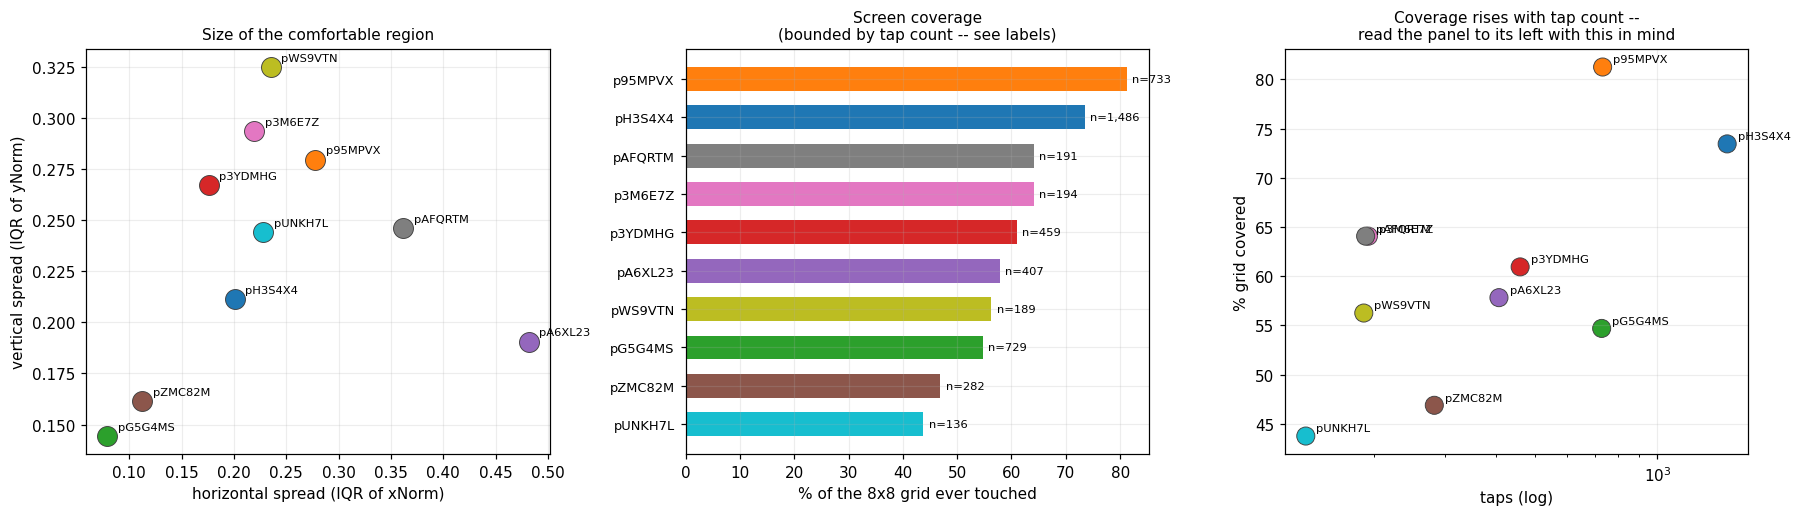

In [4]:
GRID = 8


def reach_stats(taps):
    rows = []
    for p in PARTICIPANTS:
        d = taps.loc[taps['participantId'] == p]
        gx = np.clip((d['payload_xNorm'] * GRID).astype(int), 0, GRID - 1)
        gy = np.clip((d['payload_yNorm'] * GRID).astype(int), 0, GRID - 1)
        cells = len(set(zip(gx, gy)))
        rows.append({'participant': p, 'n_taps': len(d),
                     'x_iqr': d['payload_xNorm'].quantile(.75) - d['payload_xNorm'].quantile(.25),
                     'y_iqr': d['payload_yNorm'].quantile(.75) - d['payload_yNorm'].quantile(.25),
                     'cells_touched': cells, 'coverage': cells / (GRID * GRID)})
    return pd.DataFrame(rows)


reach = reach_stats(taps)
print(reach.round(3).to_string(index=False))


def plot_reach(reach, taps):
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
    ax = axes[0]
    for _, r in reach.iterrows():
        ax.scatter(r['x_iqr'], r['y_iqr'], s=170, color=pcolor(r['participant']),
                   edgecolor='0.25', lw=0.6, zorder=3)
        ax.annotate(r['participant'], (r['x_iqr'], r['y_iqr']), fontsize=7.5,
                    xytext=(7, 4), textcoords='offset points')
    ax.set_xlabel("horizontal spread (IQR of xNorm)")
    ax.set_ylabel("vertical spread (IQR of yNorm)")
    ax.set_title("Size of the comfortable region", fontsize=10)

    ax = axes[1]
    d = reach.sort_values('coverage')
    y = np.arange(len(d))
    ax.barh(y, d['coverage'] * 100, color=[pcolor(p) for p in d['participant']], height=0.62)
    for i, r in enumerate(d.itertuples()):
        ax.text(r.coverage * 100 + 1, i, f"n={r.n_taps:,}", va='center', fontsize=7.5)
    ax.set_yticks(y); ax.set_yticklabels(d['participant'], fontsize=8.5)
    ax.set_xlabel(f"% of the {GRID}x{GRID} grid ever touched")
    ax.set_title("Screen coverage\n(bounded by tap count -- see labels)", fontsize=10)

    ax = axes[2]
    ax.scatter(reach['n_taps'], reach['coverage'] * 100,
               c=[pcolor(p) for p in reach['participant']], s=140, edgecolor='0.25', lw=0.6)
    for _, r in reach.iterrows():
        ax.annotate(r['participant'], (r['n_taps'], r['coverage'] * 100), fontsize=7.5,
                    xytext=(7, 3), textcoords='offset points')
    ax.set_xscale('log'); ax.set_xlabel("taps (log)"); ax.set_ylabel("% grid covered")
    ax.set_title("Coverage rises with tap count --\nread the panel to its left with this in mind",
                 fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_reach(reach, taps)

## 5. Horizontal bias — the handedness signal

A right thumb pivots at the bottom-right of the phone and sweeps left; a left thumb does the
mirror image. So the **horizontal centre of mass** of someone's taps is the most direct
handedness evidence available without asking them.

This is worth isolating because it is one of the very few candidate features in this project
with a clear physical mechanism that has nothing to do with speed. Handedness cannot be
"pace wearing a different hat".

The caveat kept in view throughout: the app's own layout pulls every participant toward the
same regions, so what matters is the *deviation between people*, not the absolute value.

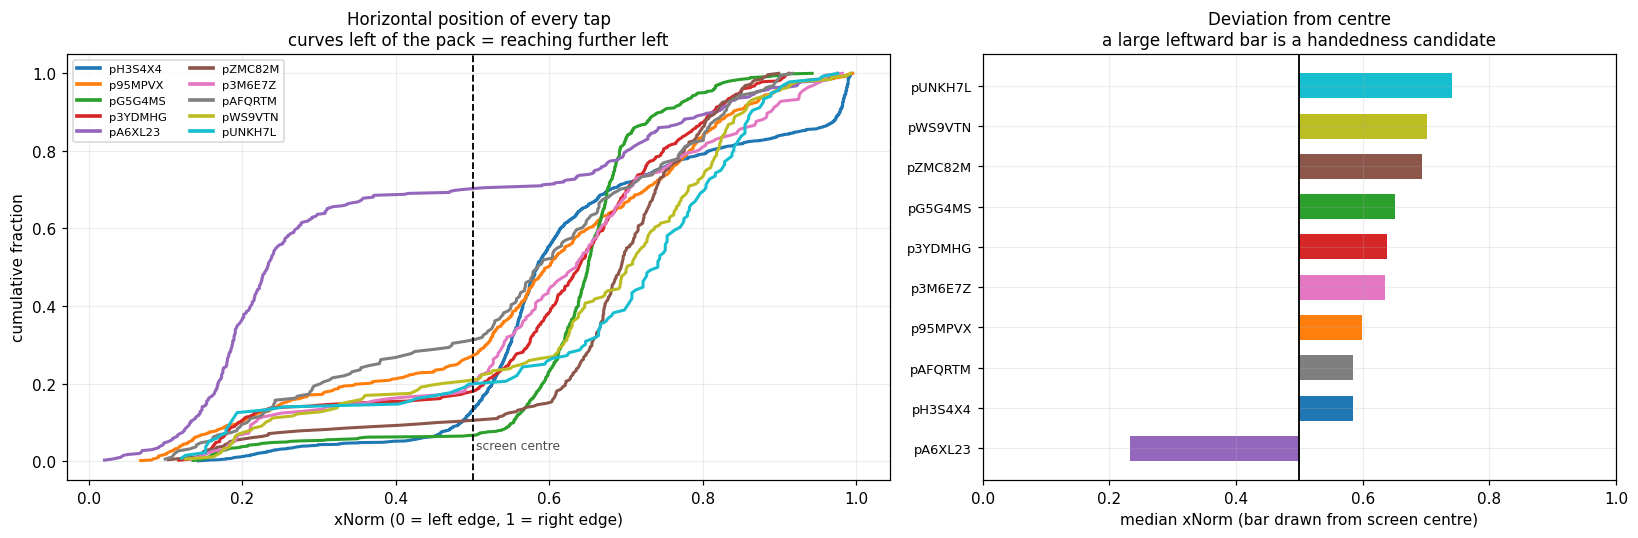

median xNorm ranges 0.233 to 0.742 across participants


In [5]:
def plot_horizontal_bias(taps):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1.3, 1]})
    ax = axes[0]
    for p in PARTICIPANTS:
        v = np.sort(taps.loc[taps['participantId'] == p, 'payload_xNorm'].to_numpy())
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=2)
    ax.axvline(0.5, color='k', ls='--', lw=1.2)
    ax.text(0.505, 0.03, "screen centre", fontsize=8, color='0.3')
    ax.set_xlabel("xNorm (0 = left edge, 1 = right edge)")
    ax.set_ylabel("cumulative fraction")
    ax.set_title("Horizontal position of every tap\ncurves left of the pack = reaching further left")
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    ax.legend(handles=handles, fontsize=7.5, ncol=2, loc='upper left')

    ax = axes[1]
    med = taps.groupby('participantId')['payload_xNorm'].median().reindex(PARTICIPANTS).sort_values()
    y = np.arange(len(med))
    ax.barh(y, med.values - 0.5, left=0.5, color=[pcolor(p) for p in med.index], height=0.62)
    ax.axvline(0.5, color='k', lw=1.2)
    ax.set_yticks(y); ax.set_yticklabels(med.index, fontsize=8.5)
    ax.set_xlim(0, 1)
    ax.set_xlabel("median xNorm (bar drawn from screen centre)")
    ax.set_title("Deviation from centre\na large leftward bar is a handedness candidate")
    plt.tight_layout(); plt.show(); plt.close(fig)
    print(f"median xNorm ranges {med.min():.3f} to {med.max():.3f} across participants")


plot_horizontal_bias(taps)

## 6. Vertical zones — what is comfortable to reach

The top of a large phone is genuinely hard to reach with the holding thumb. People either
stretch, shuffle the phone down the hand, or use a second hand — and which they do shows up
as a difference in how their taps distribute vertically.

The screen is split into three bands. The exact boundaries are arbitrary; the point is the
*relative* distribution, not the absolute share in any band.

**Read this section with Section 2's failure in mind.** `yNorm` is measured against a
viewport that halves when the keyboard opens, so a participant who types more will appear to
tap higher on the screen partly as an artifact. The comparison is still worth making — but
the vertical axis is the weakest one in this notebook, and Sections 7 and 8 are where the
trustworthy spatial evidence lives.

                n  top third  middle third  bottom third
participant                                             
pH3S4X4      1486      0.170         0.681         0.149
p95MPVX       733      0.187         0.562         0.251
pG5G4MS       729      0.040         0.520         0.440
p3YDMHG       459      0.061         0.479         0.460
pA6XL23       407      0.054         0.415         0.531
pZMC82M       282      0.025         0.596         0.379
p3M6E7Z       194      0.093         0.438         0.469
pAFQRTM       191      0.126         0.497         0.377
pWS9VTN       189      0.180         0.534         0.286
pUNKH7L       136      0.051         0.544         0.404


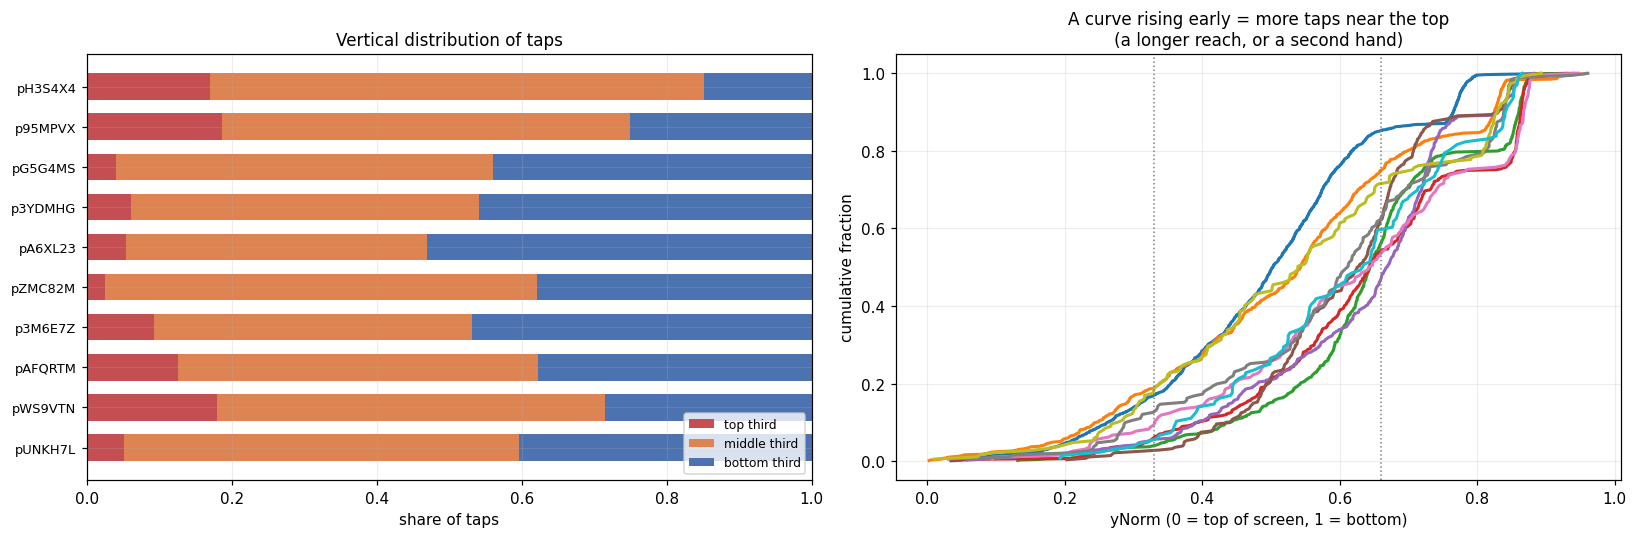

In [6]:
def plot_vertical_zones(taps):
    bands = [(0.0, 0.33, 'top third'), (0.33, 0.66, 'middle third'), (0.66, 1.01, 'bottom third')]
    rows = []
    for p in PARTICIPANTS:
        d = taps.loc[taps['participantId'] == p, 'payload_yNorm']
        rec = {'participant': p, 'n': len(d)}
        for lo, hi, name in bands:
            rec[name] = float(((d >= lo) & (d < hi)).mean())
        rows.append(rec)
    zones = pd.DataFrame(rows).set_index('participant')
    print(zones.round(3).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1.2, 1.2]})
    ax = axes[0]
    left = np.zeros(len(zones)); y = np.arange(len(zones))
    cols = ['#c44e52', '#dd8452', '#4c72b0']
    for (lo, hi, name), c in zip(bands, cols):
        ax.barh(y, zones[name], left=left, color=c, height=0.66, label=name)
        left += zones[name].to_numpy()
    ax.set_yticks(y); ax.set_yticklabels(zones.index, fontsize=8.5); ax.invert_yaxis()
    ax.set_xlim(0, 1); ax.set_xlabel("share of taps")
    ax.set_title("Vertical distribution of taps")
    ax.legend(fontsize=8, loc='lower right')

    ax = axes[1]
    for p in PARTICIPANTS:
        v = np.sort(taps.loc[taps['participantId'] == p, 'payload_yNorm'].to_numpy())
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=2)
    for lo, hi, name in bands[:-1]:
        ax.axvline(hi, color='0.5', ls=':', lw=1)
    ax.set_xlabel("yNorm (0 = top of screen, 1 = bottom)")
    ax.set_ylabel("cumulative fraction")
    ax.set_title("A curve rising early = more taps near the top\n(a longer reach, or a second hand)")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_vertical_zones(taps)

## 7. A controlled target: `continue_button`

This is the cleanest measurement in the notebook.

`continue_button` is tapped **890 times across all 29 sessions**. It is the same control, at
the same position, in the same layout, every time. Target size, target position and task
semantics are all held constant by construction — so any difference in where someone lands
is about the person and nothing else.

This removes the objection that hangs over Section 3: that the tap cloud's shape is dictated
by where the app puts things. Here the app puts the thing in exactly one place for everyone.

Two separate measurements fall out:

- **Aim point** — the systematic offset from where everyone else lands. A person who
  consistently hits left-of-centre on the same button has a real, physical aiming bias.
- **Aim scatter** — how tightly repeated taps cluster. This is precision, and it is
  independent of where the centre sits.

890 taps on 'continue_button' across 29 sessions

                 n  x_med   x_sd  y_med   y_sd  x_offset
participantId                                           
pH3S4X4        231  0.558  0.051  0.770  0.150    -0.047
p95MPVX        123  0.562  0.069  0.825  0.114    -0.043
pG5G4MS        148  0.635  0.051  0.860  0.019     0.030
p3YDMHG        131  0.611  0.065  0.860  0.051     0.006
pA6XL23         52  0.599  0.221  0.844  0.099    -0.006
pZMC82M         34  0.676  0.155  0.844  0.084     0.072
p3M6E7Z         52  0.579  0.071  0.863  0.067    -0.026
pAFQRTM         44  0.569  0.093  0.832  0.095    -0.036
pWS9VTN         48  0.646  0.059  0.823  0.108     0.041
pUNKH7L         27  0.667  0.101  0.840  0.054     0.062


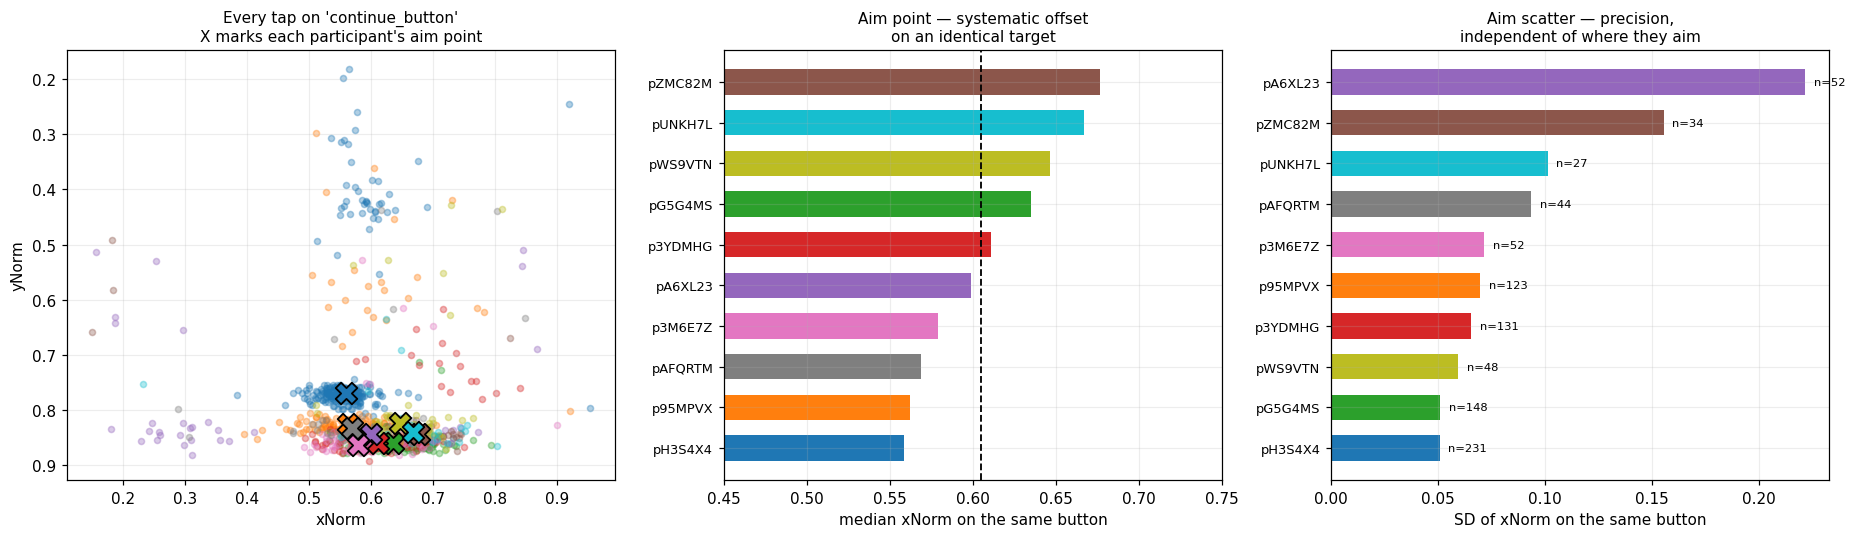


aim point spans 0.558 to 0.676
aim scatter spans 0.051 to 0.221 -- a factor of 4.4


In [7]:
CTRL_TARGET = 'continue_button'
cb = taps.loc[taps['payload_componentId'] == CTRL_TARGET].copy()
print(f"{len(cb):,} taps on '{CTRL_TARGET}' across {cb['sessionId'].nunique()} sessions\n")

cb_stats = (cb.groupby('participantId')
            .agg(n=('payload_xNorm', 'size'),
                 x_med=('payload_xNorm', 'median'), x_sd=('payload_xNorm', 'std'),
                 y_med=('payload_yNorm', 'median'), y_sd=('payload_yNorm', 'std'))
            .reindex(PARTICIPANTS))
cb_stats['x_offset'] = (cb_stats['x_med'] - cb_stats['x_med'].median()).round(3)
print(cb_stats.round(3).to_string())


def plot_controlled_target(cb, cb_stats):
    fig, axes = plt.subplots(1, 3, figsize=(17, 5), gridspec_kw={'width_ratios': [1.1, 1, 1]})

    ax = axes[0]
    for p in PARTICIPANTS:
        d = cb.loc[cb['participantId'] == p]
        if len(d) < 5:
            continue
        ax.scatter(d['payload_xNorm'], d['payload_yNorm'], s=16, alpha=0.35, color=pcolor(p))
    for p in PARTICIPANTS:
        if p in cb_stats.index and np.isfinite(cb_stats.loc[p, 'x_med']):
            ax.scatter(cb_stats.loc[p, 'x_med'], cb_stats.loc[p, 'y_med'], s=200,
                       color=pcolor(p), edgecolor='k', lw=1.2, zorder=6, marker='X')
    ax.set_xlabel("xNorm"); ax.set_ylabel("yNorm")
    ax.invert_yaxis()
    ax.set_title(f"Every tap on '{CTRL_TARGET}'\nX marks each participant's aim point", fontsize=10)

    ax = axes[1]
    d = cb_stats.dropna(subset=['x_med']).sort_values('x_med')
    y = np.arange(len(d))
    ax.barh(y, d['x_med'], color=[pcolor(p) for p in d.index], height=0.62)
    ax.axvline(d['x_med'].median(), color='k', ls='--', lw=1.2)
    ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=8.5)
    ax.set_xlim(0.45, 0.75)
    ax.set_xlabel("median xNorm on the same button")
    ax.set_title("Aim point — systematic offset\non an identical target", fontsize=10)

    ax = axes[2]
    d2 = cb_stats.dropna(subset=['x_sd']).sort_values('x_sd')
    y = np.arange(len(d2))
    ax.barh(y, d2['x_sd'], color=[pcolor(p) for p in d2.index], height=0.62)
    for i, p in enumerate(d2.index):
        ax.text(d2.loc[p, 'x_sd'] + 0.004, i, f"n={int(d2.loc[p,'n'])}", va='center', fontsize=7.5)
    ax.set_yticks(y); ax.set_yticklabels(d2.index, fontsize=8.5)
    ax.set_xlabel("SD of xNorm on the same button")
    ax.set_title("Aim scatter — precision,\nindependent of where they aim", fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)
    print(f"\naim point spans {cb_stats['x_med'].min():.3f} to {cb_stats['x_med'].max():.3f}")
    print(f"aim scatter spans {cb_stats['x_sd'].min():.3f} to {cb_stats['x_sd'].max():.3f} "
          f"-- a factor of {cb_stats['x_sd'].max()/cb_stats['x_sd'].min():.1f}")


plot_controlled_target(cb, cb_stats)

## 8. A controlled keypad: the passcode

A second natural control, and a stricter one. The passcode keypad appears in every session
with ten fixed keys (`code_key_0` through `code_key_9`) at fixed positions.

Where `continue_button` gives one target, this gives **ten targets in a known spatial
layout** — so it measures not just where someone aims at a single control, but how their
aiming bias varies across the screen. A thumb pivoting at the bottom-right should show a
different offset on the far key than the near one.

Support is thin: 4 digits per session. That is stated on every panel rather than buried.

117 taps on passcode keys, 29 sessions, 10 distinct keys

      n      x      y
key                  
0     7  0.517  0.842
1    13  0.211  0.543
2    19  0.514  0.539
3     5  0.816  0.551
4    20  0.234  0.638
5     7  0.520  0.641
6    16  0.805  0.648
7     5  0.226  0.734
8    18  0.521  0.740
9     7  0.781  0.725


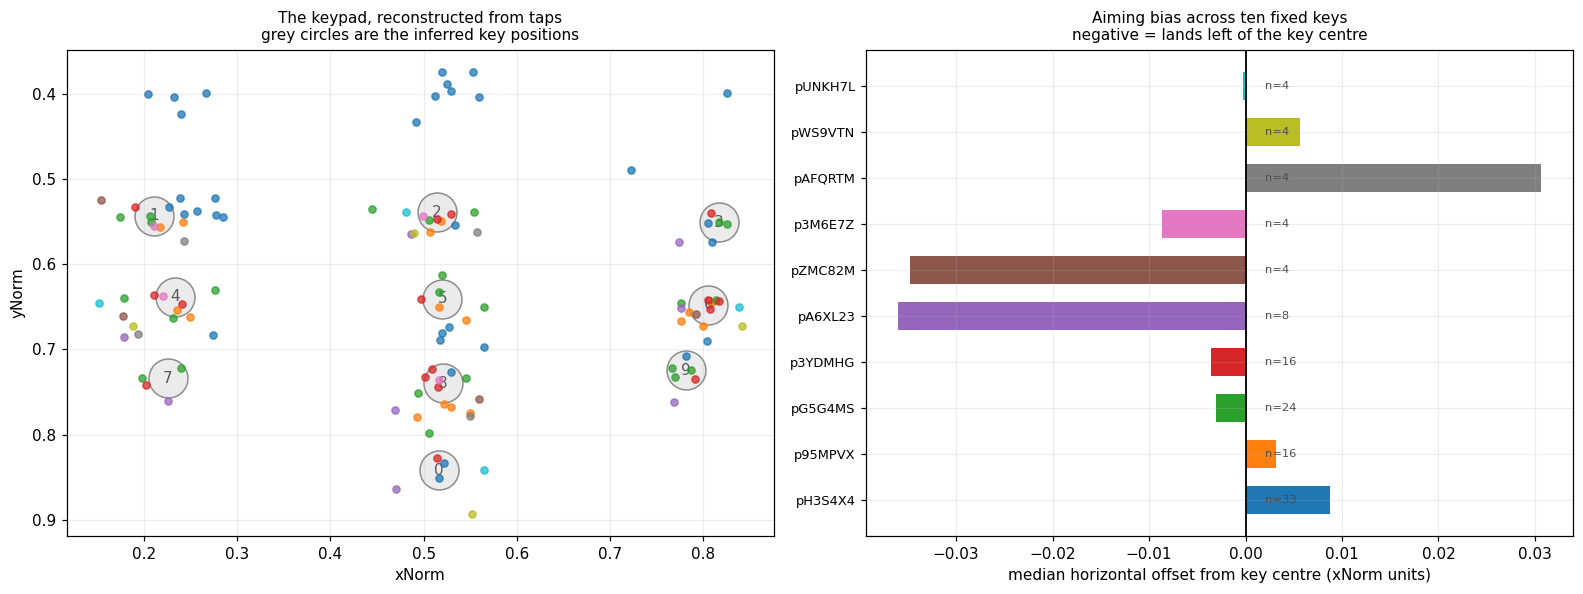

In [8]:
pc = raw.loc[raw['kind'] == 'passcode_digit_tap'].copy()
pc_taps = taps.loc[taps['payload_componentId'].astype(str).str.startswith('code_key_')].copy()
pc_taps['key'] = pc_taps['payload_componentId'].astype(str).str.replace('code_key_', '', regex=False)
print(f"{len(pc_taps)} taps on passcode keys, {pc_taps['sessionId'].nunique()} sessions, "
      f"{pc_taps['key'].nunique()} distinct keys\n")
print(pc_taps.groupby('key').agg(n=('payload_xNorm', 'size'),
                                 x=('payload_xNorm', 'median'),
                                 y=('payload_yNorm', 'median')).round(3).to_string())


def plot_keypad(pc_taps):
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.5))
    ax = axes[0]
    key_pos = pc_taps.groupby('key')[['payload_xNorm', 'payload_yNorm']].median()
    for k, r in key_pos.iterrows():
        ax.scatter(r['payload_xNorm'], r['payload_yNorm'], s=650, facecolor='0.92',
                   edgecolor='0.55', lw=1, zorder=1)
        ax.text(r['payload_xNorm'], r['payload_yNorm'], k, ha='center', va='center',
                fontsize=10, zorder=2, color='0.35')
    for p in PARTICIPANTS:
        d = pc_taps.loc[pc_taps['participantId'] == p]
        if len(d) < 3:
            continue
        ax.scatter(d['payload_xNorm'], d['payload_yNorm'], s=22, alpha=0.75, color=pcolor(p),
                   zorder=3)
    ax.invert_yaxis()
    ax.set_xlabel("xNorm"); ax.set_ylabel("yNorm")
    ax.set_title("The keypad, reconstructed from taps\ngrey circles are the inferred key positions",
                 fontsize=10)

    ax = axes[1]
    pc_taps = pc_taps.merge(key_pos.rename(columns={'payload_xNorm': 'kx', 'payload_yNorm': 'ky'}),
                            left_on='key', right_index=True, how='left')
    pc_taps['dx'] = pc_taps['payload_xNorm'] - pc_taps['kx']
    off = (pc_taps.groupby('participantId')
           .agg(n=('dx', 'size'), dx_med=('dx', 'median'), dx_sd=('dx', 'std'))
           .reindex(PARTICIPANTS).dropna(subset=['dx_med']))
    y = np.arange(len(off))
    ax.barh(y, off['dx_med'], color=[pcolor(p) for p in off.index], height=0.62)
    ax.axvline(0, color='k', lw=1.2)
    for i, p in enumerate(off.index):
        ax.text(0.002, i, f"n={int(off.loc[p,'n'])}", va='center', fontsize=7.5, color='0.3')
    ax.set_yticks(y); ax.set_yticklabels(off.index, fontsize=8.5)
    ax.set_xlabel("median horizontal offset from key centre (xNorm units)")
    ax.set_title("Aiming bias across ten fixed keys\nnegative = lands left of the key centre",
                 fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)
    return off


keypad_offsets = plot_keypad(pc_taps)

## 9. Aim precision on a fixed target

Sections 7 and 8 both produce a *scatter* measurement — how tightly repeated taps on the
same control cluster. This section brings them together, because precision is conceptually
separate from position and may behave differently.

Someone can aim consistently off-centre (a large offset, small scatter) or aim correctly on
average while being erratic (small offset, large scatter). These are different motor
properties and a single "accuracy" number would merge them.

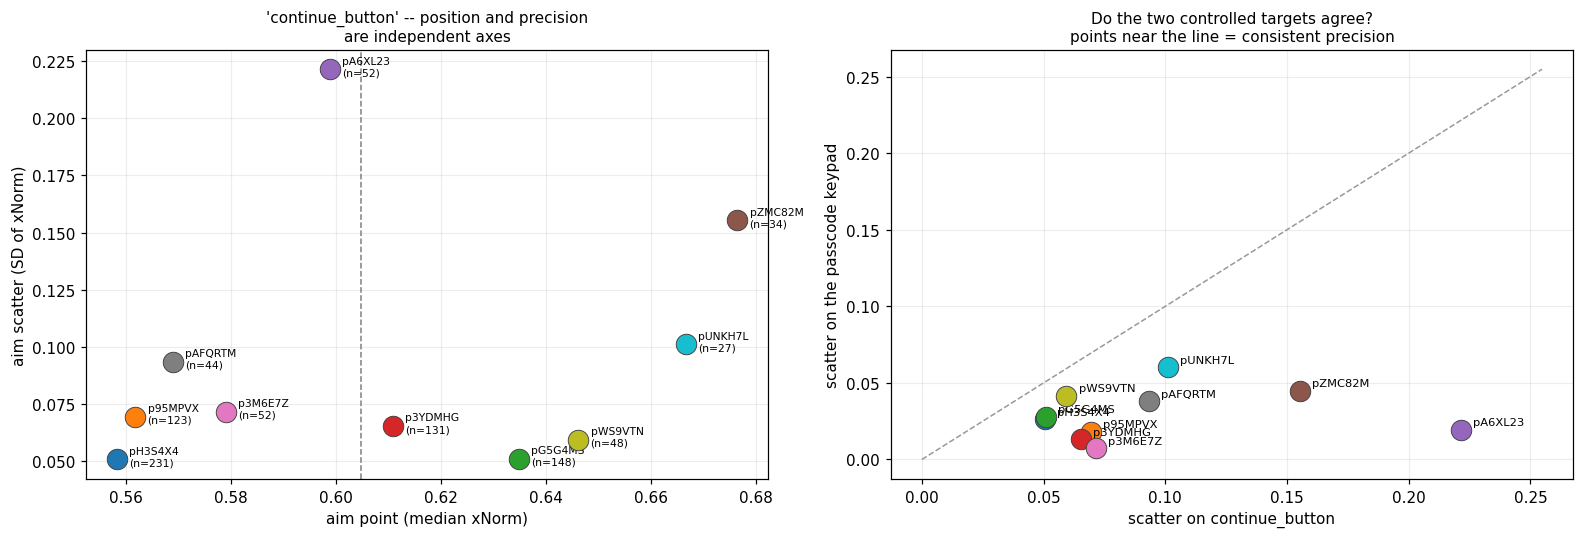

In [9]:
def plot_precision(cb_stats, keypad_offsets):
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5))
    ax = axes[0]
    d = cb_stats.dropna(subset=['x_med', 'x_sd'])
    for p, r in d.iterrows():
        ax.scatter(r['x_med'], r['x_sd'], s=180, color=pcolor(p), edgecolor='0.25',
                   lw=0.6, zorder=3)
        ax.annotate(f"{p}\n(n={int(r['n'])})", (r['x_med'], r['x_sd']), fontsize=7,
                    xytext=(8, -4), textcoords='offset points')
    ax.axvline(d['x_med'].median(), color='0.5', ls='--', lw=1)
    ax.set_xlabel("aim point (median xNorm)")
    ax.set_ylabel("aim scatter (SD of xNorm)")
    ax.set_title(f"'{CTRL_TARGET}' -- position and precision\nare independent axes", fontsize=10)

    ax = axes[1]
    both = cb_stats[['x_sd']].join(keypad_offsets[['dx_sd']], how='inner').dropna()
    for p, r in both.iterrows():
        ax.scatter(r['x_sd'], r['dx_sd'], s=180, color=pcolor(p), edgecolor='0.25',
                   lw=0.6, zorder=3)
        ax.annotate(p, (r['x_sd'], r['dx_sd']), fontsize=7.5,
                    xytext=(8, 3), textcoords='offset points')
    lim = [0, max(both['x_sd'].max(), both['dx_sd'].max()) * 1.15]
    ax.plot(lim, lim, ls='--', color='0.6', lw=1)
    ax.set_xlabel("scatter on continue_button")
    ax.set_ylabel("scatter on the passcode keypad")
    ax.set_title("Do the two controlled targets agree?\npoints near the line = consistent precision",
                 fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_precision(cb_stats, keypad_offsets)

## 10. Contact size — what the touch radius reveals

`payload_radiusX` is the reported contact ellipse radius: how much of the finger is touching
the glass. Physically this is a mix of finger size and how firmly the tap is pressed.

**It is heavily device-quantised.** Each handset reports radius in multiples of a
model-specific base unit, so the raw value is partly hardware. What is *not* fixed by the
hardware is the **distribution over those quanta** — how often someone produces a light
contact versus a firm one.

So the comparison to make is not "who has a bigger radius" (that is the phone) but "what
does each person's mix of contact sizes look like".

radiusX values per device model -- note the quantisation:

  iphone_13_13_mini        n=1,486  distinct=  2  first few: [np.float64(12.58), np.float64(25.16)]
  iphone_13_pro_pro_max    n=  189  distinct=  2  first few: [np.float64(12.14), np.float64(24.29)]
  iphone_15                n=  282  distinct=  3  first few: [np.float64(12.09), np.float64(24.17), np.float64(36.26)]
  iphone_16                n=  407  distinct=  4  first few: [np.float64(12.09), np.float64(24.17), np.float64(36.26), np.float64(48.34)]
  iphone_16_plus           n=1,382  distinct=  4  first few: [np.float64(12.1), np.float64(24.21), np.float64(36.31), np.float64(48.42)]
  older_iphone             n=1,060  distinct=  6  first few: [np.float64(12.58), np.float64(12.88), np.float64(25.16), np.float64(25.77), np.float64(37.74), np.float64(38.66)]


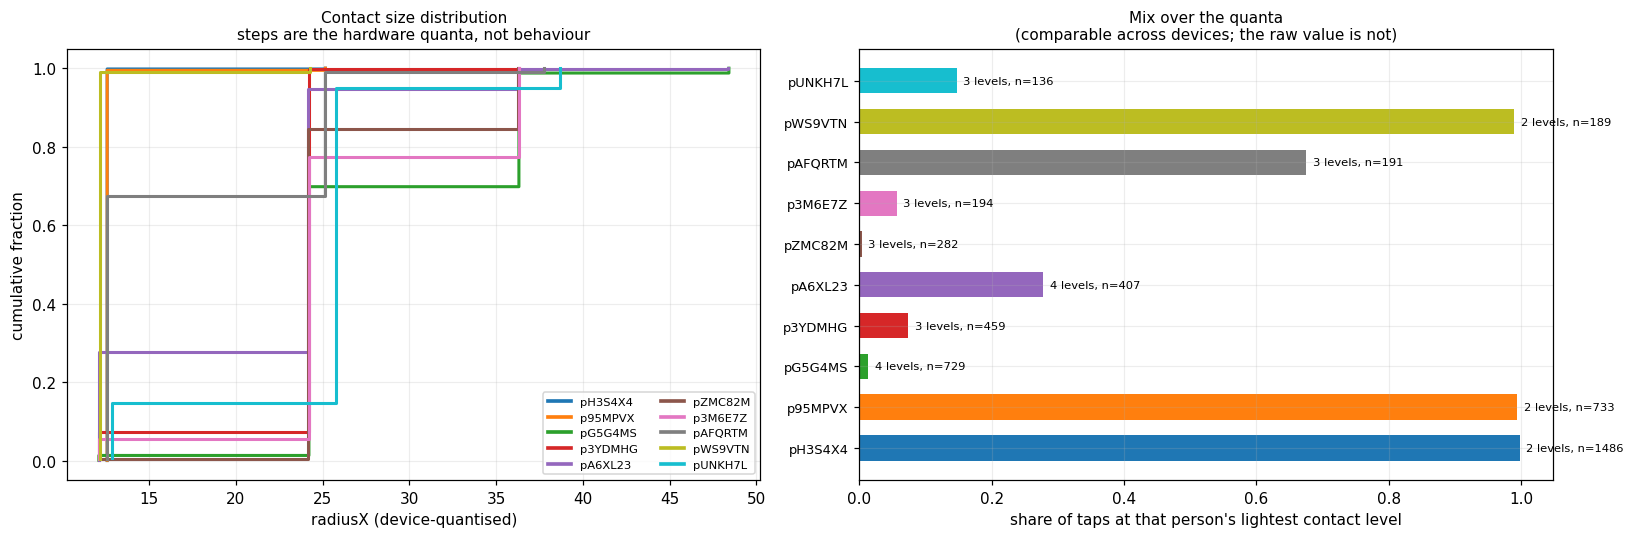

In [10]:
rad = taps.dropna(subset=['payload_radiusX'])
print("radiusX values per device model -- note the quantisation:\n")
for mod, g in rad.groupby(rad['sessionId'].map(
        session_index.set_index('sessionId')['device'])):
    vals = sorted(g['payload_radiusX'].unique())[:6]
    print(f"  {mod:24s} n={len(g):5,}  distinct={g['payload_radiusX'].nunique():3d}  "
          f"first few: {[round(v,2) for v in vals]}")


def plot_contact_size(rad):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    ax = axes[0]
    for p in PARTICIPANTS:
        v = np.sort(rad.loc[rad['participantId'] == p, 'payload_radiusX'].to_numpy())
        if len(v) < 30:
            continue
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=2,
                drawstyle='steps-post')
    ax.set_xlabel("radiusX (device-quantised)")
    ax.set_ylabel("cumulative fraction")
    ax.set_title("Contact size distribution\nsteps are the hardware quanta, not behaviour",
                 fontsize=10)
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    ax.legend(handles=handles, fontsize=7.5, ncol=2, loc='lower right')

    ax = axes[1]
    rows = []
    for p in PARTICIPANTS:
        d = rad.loc[rad['participantId'] == p, 'payload_radiusX']
        if len(d) < 30:
            continue
        # share of taps at the SMALLEST quantum that person produces -- a light-touch measure
        q = d.min()
        rows.append({'p': p, 'n': len(d), 'light_share': float((d <= q).mean()),
                     'n_quanta': d.nunique()})
    q = pd.DataFrame(rows).set_index('p')
    y = np.arange(len(q))
    ax.barh(y, q['light_share'], color=[pcolor(p) for p in q.index], height=0.62)
    for i, p in enumerate(q.index):
        ax.text(q.loc[p, 'light_share'] + 0.01, i,
                f"{int(q.loc[p,'n_quanta'])} levels, n={int(q.loc[p,'n'])}",
                va='center', fontsize=7.5)
    ax.set_yticks(y); ax.set_yticklabels(q.index, fontsize=8.5)
    ax.set_xlabel("share of taps at that person's lightest contact level")
    ax.set_title("Mix over the quanta\n(comparable across devices; the raw value is not)",
                 fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_contact_size(rad)

## 11. Spatial drift across a session

Everything so far pools a whole session into one cloud. This asks whether the cloud
**moves** during a session — which it would if someone shifts their grip, gets tired, or
settles into a more comfortable hold as they go.

The measurement is the median `xNorm` in each quarter of the session, per participant. A
flat line means a stable grip; a trend means the hand is migrating.

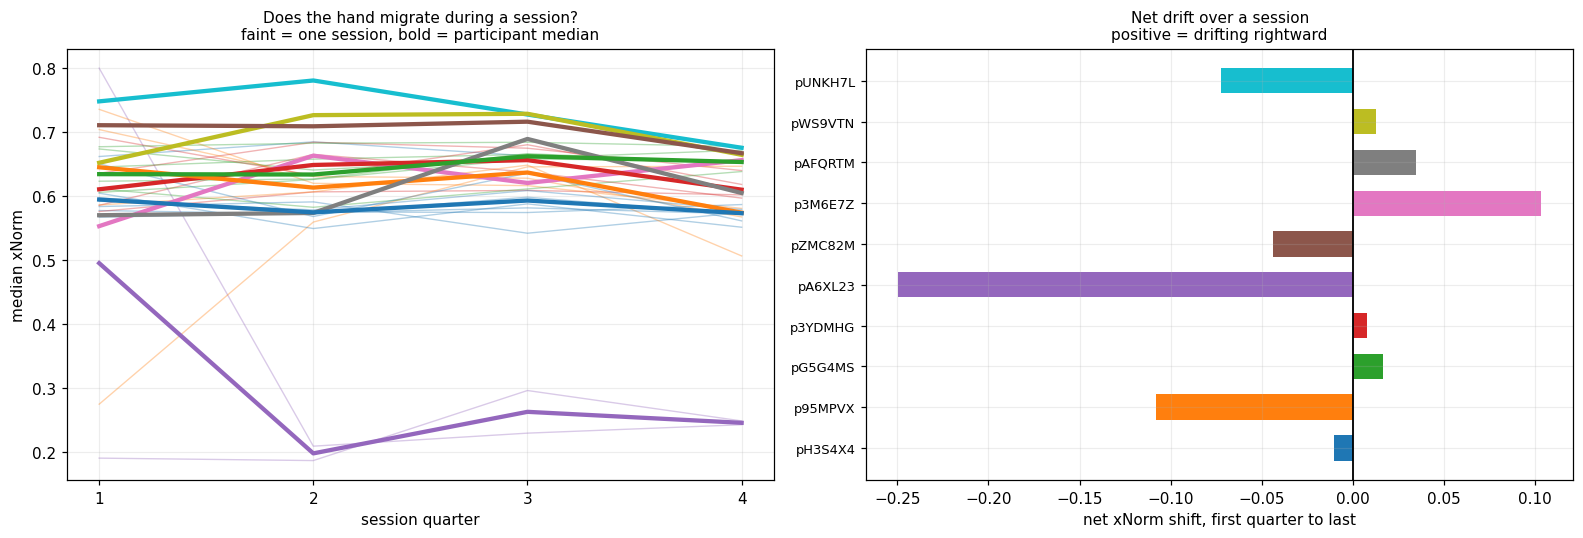

In [11]:
def plot_spatial_drift(taps):
    N_Q = 4
    rows = []
    for sid, g in taps.groupby('sessionId'):
        dur = g['tRelMs'].max()
        if dur <= 0 or len(g) < 40:
            continue
        edges = np.linspace(0, dur, N_Q + 1)
        for i in range(N_Q):
            sel = g.loc[(g['tRelMs'] >= edges[i]) & (g['tRelMs'] < edges[i + 1])]
            if len(sel) >= 8:
                rows.append({'participantId': g['participantId'].iloc[0], 'sessionId': sid,
                             'q': i + 1, 'x_med': sel['payload_xNorm'].median()})
    drift = pd.DataFrame(rows)

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 5))
    ax = axes[0]
    for sid, g in drift.groupby('sessionId'):
        p = g['participantId'].iloc[0]
        ax.plot(g['q'], g['x_med'], color=pcolor(p), lw=0.9, alpha=0.35)
    med = drift.groupby(['participantId', 'q'])['x_med'].median().reset_index()
    for p, g in med.groupby('participantId'):
        ax.plot(g['q'], g['x_med'], color=pcolor(p), lw=2.8)
    ax.set_xticks(range(1, N_Q + 1))
    ax.set_xlabel("session quarter"); ax.set_ylabel("median xNorm")
    ax.set_title("Does the hand migrate during a session?\nfaint = one session, bold = participant median",
                 fontsize=10)

    ax = axes[1]
    net = (drift.pivot_table(index=['participantId', 'sessionId'], columns='q', values='x_med'))
    if N_Q in net.columns and 1 in net.columns:
        net['shift'] = net[N_Q] - net[1]
        agg = net.groupby('participantId')['shift'].median().reindex(PARTICIPANTS).dropna()
        y = np.arange(len(agg))
        ax.barh(y, agg.values, color=[pcolor(p) for p in agg.index], height=0.62)
        ax.axvline(0, color='k', lw=1.2)
        ax.set_yticks(y); ax.set_yticklabels(agg.index, fontsize=8.5)
        ax.set_xlabel("net xNorm shift, first quarter to last")
        ax.set_title("Net drift over a session\npositive = drifting rightward", fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_spatial_drift(taps)

## 12. Gesture geometry — where strokes start and end

A scroll or swipe is not just a magnitude; it happens somewhere. Where a stroke **begins**
is a grip signature — it is the point the thumb naturally falls to before moving — and it is
measured independently of anything in notebook 06, which treated gestures purely as
distances and durations.

2,378 strokes with >=3 move samples

                  n  x0_med  y0_med
participantId                      
pH3S4X4        1071   0.689   0.509
p95MPVX         401   0.741   0.489
pG5G4MS         159   0.709   0.587
p3YDMHG         167   0.727   0.611
pA6XL23         158   0.206   0.620
pZMC82M          84   0.772   0.567
p3M6E7Z         108   0.837   0.626
pAFQRTM          85   0.704   0.591
pWS9VTN          87   0.807   0.485
pUNKH7L          58   0.824   0.626


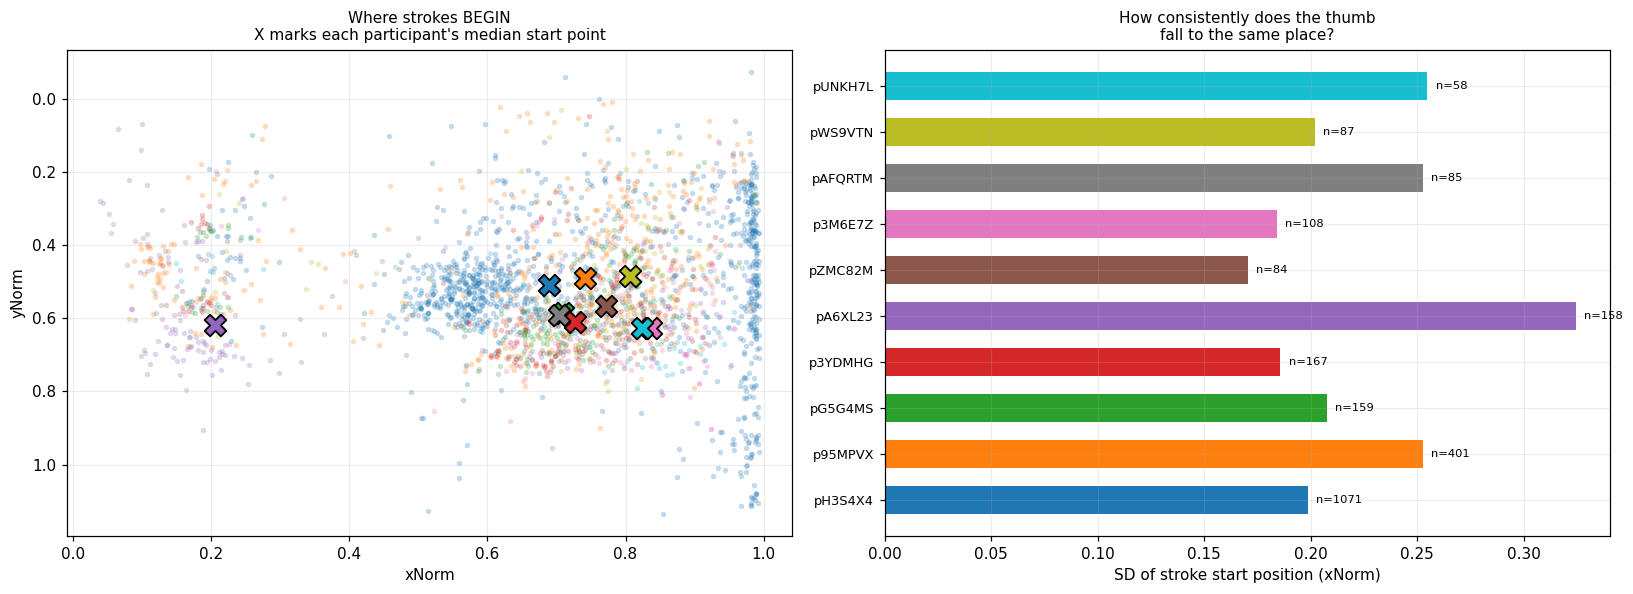

In [12]:
moves = raw.loc[raw['kind'] == 'touchmove'].copy()
for c in ['payload_xNorm', 'payload_yNorm']:
    moves[c] = pd.to_numeric(moves[c], errors='coerce')
moves = moves.dropna(subset=['payload_xNorm', 'payload_yNorm'])


def stroke_endpoints(taps, moves):
    rows = []
    for sid, g in moves.groupby('sessionId'):
        g = g.sort_values('tRelMs')
        t = g['tRelMs'].to_numpy(float)
        brk = np.where(np.diff(t) > 300)[0]
        idx = np.split(np.arange(len(g)), brk + 1)
        gx = g['payload_xNorm'].to_numpy(); gy = g['payload_yNorm'].to_numpy()
        for run in idx:
            if len(run) < 3:
                continue
            rows.append({'participantId': g['participantId'].iloc[0], 'sessionId': sid,
                         'x0': gx[run[0]], 'y0': gy[run[0]],
                         'x1': gx[run[-1]], 'y1': gy[run[-1]], 'n': len(run)})
    return pd.DataFrame(rows)


strokes = stroke_endpoints(taps, moves)
print(f"{len(strokes):,} strokes with >=3 move samples\n")
print(strokes.groupby('participantId').agg(n=('x0', 'size'), x0_med=('x0', 'median'),
                                           y0_med=('y0', 'median')).reindex(PARTICIPANTS).round(3).to_string())


def plot_strokes(strokes):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    ax = axes[0]
    for p in PARTICIPANTS:
        d = strokes.loc[strokes['participantId'] == p]
        if len(d) < 20:
            continue
        ax.scatter(d['x0'], d['y0'], s=7, alpha=0.2, color=pcolor(p))
        ax.scatter(d['x0'].median(), d['y0'].median(), s=200, color=pcolor(p),
                   edgecolor='k', lw=1.2, marker='X', zorder=6)
    ax.invert_yaxis(); ax.set_xlabel("xNorm"); ax.set_ylabel("yNorm")
    ax.set_title("Where strokes BEGIN\nX marks each participant's median start point", fontsize=10)

    ax = axes[1]
    d = strokes.groupby('participantId').agg(x0=('x0', 'median'), x0_sd=('x0', 'std'),
                                             n=('x0', 'size')).reindex(PARTICIPANTS).dropna()
    d = d.loc[d['n'] >= 20]
    y = np.arange(len(d))
    ax.barh(y, d['x0_sd'], color=[pcolor(p) for p in d.index], height=0.62)
    for i, p in enumerate(d.index):
        ax.text(d.loc[p, 'x0_sd'] + 0.004, i, f"n={int(d.loc[p,'n'])}", va='center', fontsize=7.5)
    ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=8.5)
    ax.set_xlabel("SD of stroke start position (xNorm)")
    ax.set_title("How consistently does the thumb\nfall to the same place?", fontsize=10)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_strokes(strokes)

## 13. Does any of this hold within a person?

The question that decides whether any of the above is a trait rather than a description.
Each participant's session-level values are plotted as points joined by a line — **short
vertical spread means the pooled numbers above are trustworthy; a long line means they were
hiding session-to-session variation.**

Shown without a verdict. Five participants now have four or more sessions, which is the best
support this project has had for this check, but it is still five people.

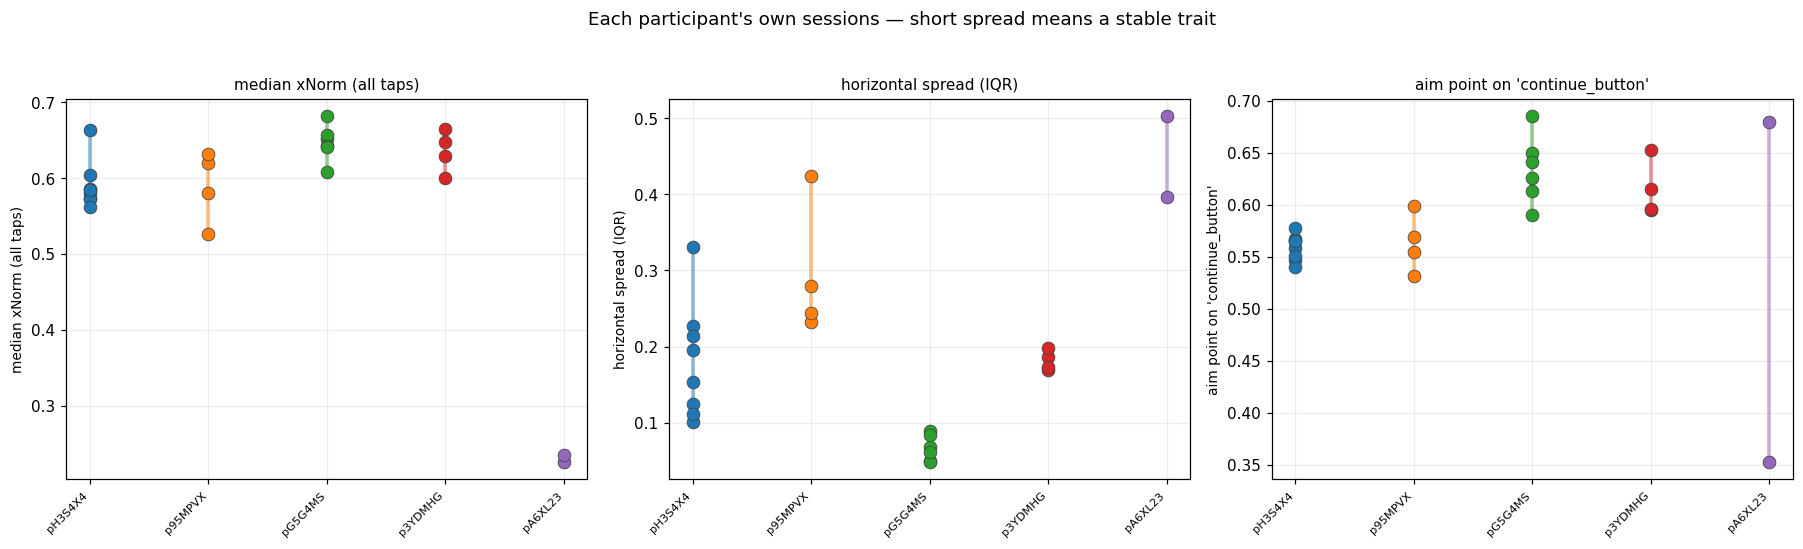

participants with >1 session: pH3S4X4, p95MPVX, pG5G4MS, p3YDMHG, pA6XL23


In [13]:
def plot_within_person(taps, cb):
    multi = [p for p in PARTICIPANTS if (session_index['participantId'] == p).sum() > 1]
    sess_all = (taps.groupby(['participantId', 'sessionId'])
                .agg(x_med=('payload_xNorm', 'median'),
                     x_iqr=('payload_xNorm', lambda s: s.quantile(.75) - s.quantile(.25)),
                     n=('payload_xNorm', 'size')).reset_index())
    sess_cb = (cb.groupby(['participantId', 'sessionId'])
               .agg(cb_x=('payload_xNorm', 'median'), n=('payload_xNorm', 'size')).reset_index())
    sess_cb = sess_cb.loc[sess_cb['n'] >= 5]

    panels = [(sess_all, 'x_med', 'median xNorm (all taps)'),
              (sess_all, 'x_iqr', 'horizontal spread (IQR)'),
              (sess_cb, 'cb_x', f"aim point on '{CTRL_TARGET}'")]
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
    for ax, (src, col, lab) in zip(axes, panels):
        for i, p in enumerate(multi):
            v = src.loc[src['participantId'] == p, col].dropna().to_numpy()
            if len(v) == 0:
                continue
            ax.scatter(np.full(len(v), i), v, s=70, color=pcolor(p), edgecolor='0.25',
                       lw=0.5, zorder=3)
            if len(v) > 1:
                ax.plot([i, i], [v.min(), v.max()], color=pcolor(p), lw=2.4, alpha=0.5, zorder=2)
        ax.set_xticks(range(len(multi)))
        ax.set_xticklabels(multi, rotation=45, ha='right', fontsize=7.5)
        ax.set_ylabel(lab, fontsize=9); ax.set_title(lab, fontsize=10)
    fig.suptitle("Each participant's own sessions — short spread means a stable trait", y=1.03)
    plt.tight_layout(); plt.show(); plt.close(fig)
    print(f"participants with >1 session: {', '.join(multi)}")


plot_within_person(taps, cb)

## 14. Availability and data-quality notes

- **`yNorm` is viewport-relative, not screen-relative** (Section 2). The visual viewport
  loses roughly half its height when the keyboard opens — 605 px down to 187 px in one
  session, through 102 intermediate values as it animates. Any vertical comparison between a
  typing task and a non-typing one is contaminated. **`xNorm` is unaffected**, because
  viewport width does not change with the keyboard, and it is used as the primary spatial
  measure throughout.
- **Aspect ratio differs across devices** (1.64 to 1.87 here), so equal `yNorm` does not mean
  equal physical distance from the thumb pivot even when the keyboard is closed.
- **`componentId` is missing on ~16% of taps**, so target-conditioned analysis (Sections 7-9)
  covers most but not all of the data.
- **`radiusX` is device-quantised.** Raw values are hardware; only the distribution over a
  device's own quanta is comparable across participants (Section 10).
- **The whole-cloud analyses (Sections 3-6) are shaped by app layout.** Everyone is pushed
  toward the same controls, so those sections describe where the app puts things as much as
  where the person reaches. Sections 7 and 8 exist because they do not have this problem.
- **Passcode support is thin** — 4 digits per session, so per-participant keypad statistics
  rest on tens of taps at best.
- **Handedness is inferred, never observed.** No participant reported which hand they used.
  Section 5 identifies a candidate signal; it has not been validated against ground truth.

## 15. Per-participant cards

In [14]:
card = pd.DataFrame(index=PARTICIPANTS)
card['sessions'] = session_index.groupby('participantId').size().reindex(PARTICIPANTS)
card['taps'] = taps.groupby('participantId').size().reindex(PARTICIPANTS)
card['x_median'] = taps.groupby('participantId')['payload_xNorm'].median().reindex(PARTICIPANTS).round(3)
card['x_iqr'] = (taps.groupby('participantId')['payload_xNorm']
                 .apply(lambda s: s.quantile(.75) - s.quantile(.25))).reindex(PARTICIPANTS).round(3)
card['y_median'] = taps.groupby('participantId')['payload_yNorm'].median().reindex(PARTICIPANTS).round(3)
card['coverage_pct'] = (reach.set_index('participant')['coverage'] * 100).round(1)
card['cb_aim_x'] = cb_stats['x_med'].round(3)
card['cb_scatter'] = cb_stats['x_sd'].round(3)
card['cb_n'] = cb_stats['n']
card['keypad_offset'] = keypad_offsets['dx_med'].round(4)
card['stroke_start_x'] = strokes.groupby('participantId')['x0'].median().reindex(PARTICIPANTS).round(3)

print("Blank cells mean the quantity could not be computed for that person.")
print("yNorm-derived columns carry the Section 2 caveat.\n")
print(card.to_string())

Blank cells mean the quantity could not be computed for that person.
yNorm-derived columns carry the Section 2 caveat.

         sessions  taps  x_median  x_iqr  y_median  coverage_pct  cb_aim_x  cb_scatter  cb_n  keypad_offset  stroke_start_x
pH3S4X4         8  1486     0.584  0.201     0.503          73.4     0.558       0.051   231         0.0087           0.689
p95MPVX         4   733     0.598  0.277     0.543          81.2     0.562       0.069   123         0.0032           0.741
pG5G4MS         6   729     0.650  0.079     0.644          54.7     0.635       0.051   148        -0.0031           0.709
p3YDMHG         4   459     0.639  0.176     0.643          60.9     0.611       0.065   131        -0.0036           0.727
pA6XL23         2   407     0.233  0.482     0.669          57.8     0.599       0.221    52        -0.0360           0.206
pZMC82M         1   282     0.694  0.112     0.627          46.9     0.676       0.155    34        -0.0348           0.772
p3M6E7Z     

## 16. Open questions

- **Handedness is the most promising lead here and is completely unvalidated.** Section 5
  shows a candidate horizontal signal with a clear physical mechanism and no route back to
  pace — which is rare in this project. It could be settled immediately by asking
  participants which hand they use. That single question would convert an inference into a
  labelled ground truth, and it costs nothing.
- **The controlled-target result (Section 7) deserves a proper stability test.** Aim point
  and aim scatter on `continue_button` are the cleanest spatial measurements available, with
  890 observations and no task confound by construction. Whether they replicate within a
  person across sessions is the obvious next question and Section 13 only gestures at it.
- **`yNorm` could be repaired rather than caveated.** The viewport height at each moment is
  recoverable from `visual_viewport_resize`, so a screen-relative y-coordinate could be
  reconstructed by dividing raw `payload_y` by the *layout* viewport rather than the visual
  one. That would unlock the vertical axis, which this notebook currently treats as
  second-class.
- **Target geometry is still not logged.** Without element bounding boxes there is no way to
  compute distance-to-target-centre properly, which is what a Fitts-style analysis of
  speed-accuracy tradeoff would need. Section 8 approximates it by inferring key positions
  from the taps themselves, which is circular.
- **Nothing here is conditioned on gesture class.** A tap that begins a scroll and a tap that
  presses a button may land in systematically different places, and notebook 06 already has
  the classification needed to separate them.
- **Every participant is still on their own device.** Contact radius in particular is
  strongly device-mediated, and screen size differences remain a confound for any measure
  that survives normalisation.